# SOC fix — stop the model from overusing the batteries

**The problem (from the bottleneck study, `constraints/results/study_summary.md`):**
the demand-responsive model (`itransformer_rayenfd`) meets a simulated load increase,
but it makes the **batteries** do most of the work. Why: when demand changes, the head
splits the correction between power sources *proportional to how fast each can change*
— and batteries are the fastest (~54% of the fleet's 5-minute ramp capacity: charging
can drop 863 MW + discharging can rise 715 MW, vs hydro 791, coal 268, ocgt 263).
So battery output responds +53% at a +10% load increase (+183% at +30%) while coal
moves only ~4–8%, and with no memory of how full the battery is, the daily energy
swing blows past the physical storage (worst day 101% → 134% of capacity; 553% in
stress episodes).

**The two fixes (both implemented in `lib/models.py::RayenHeadFixedD`):**

1. **Smarter split** (`--fd-alloc`): give corrections to the sources we trust, not the
   fastest ones — `invvar` = weight by 1/error-variance (MinT reconciliation theory),
   `share` = weight by each source's real share of energy (coal carries most).
2. **Fuel gauge / SOC shield** (`--soc-shield on`): the rollout tracks the battery's
   state of charge from the model's own predictions and hands the head per-step
   battery *level caps*, so charging can never overfill nor discharging overdrain
   the reservoir — a hard per-day guarantee (safety-layer / control-barrier family;
   see `constraints/lit_review.md` themes 5–6).

**Deliverables:** the variant comparison table, and the 4-day all-energy stacked
graph (actual / baseline / scenario) for the best variant.


In [1]:
REPO = "github.com/nm-quan/energy_modelling.git"
TOKEN = ""   # repo is PRIVATE: paste a fine-grained READ-ONLY token (Contents: read)
BRANCH = "claude/model-bottlenecks-constraints-gb1aoj"   # set to "main" once merged
import os
url = f"https://{TOKEN + '@' if TOKEN else ''}{REPO}"
if not os.path.exists("energy_modelling"):
    !git clone -q --branch $BRANCH $url
%cd energy_modelling
!git pull -q
!nvidia-smi -L


/content/energy_modelling
GPU 0: Tesla T4 (UUID: GPU-6a200492-8929-f27d-c8ee-00c8bb65517e)


## 1 · Reproduce the problem — baseline (headroom split, no shield)

Rollouts are sequential, a few minutes per model. The baseline rows also ship
committed in `demand_simulation/sweep_eqnd/study/`, so this is reproduction, not
discovery.


In [2]:
!python demand_simulation/study_shift.py --scenario increase --g 10 --models rayenfd
!python demand_simulation/study_shift.py --scenario increase --g 30 --models rayenfd


device=cuda scenario=increase g=10.0
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
models: ['itransformer_rayenfd+spt']
  itransformer_rayenfd+spt base_WAPE=2.3236 capture=+1.029 track_p50=78 MW ramp=181 (seam 179) soc_day=99% (172.6s)
wrote /content/energy_modelling/demand_simulation/sweep_eqnd/study/increase_g10.md
device=cuda scenario=increase g=30.0
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
models: ['itransformer_rayenfd+spt']
  itransformer_rayenfd+spt base_WAPE=2.3236 capture=+1.029 track_p50=91 MW ramp=259 (seam 169) soc_day=89% (170.4s)
wrote /content/energy_modelling/demand_simulation/sweep_eqnd/study/incr

## 2 · Fix 1 — smarter split of the demand correction


In [3]:
!python demand_simulation/study_shift.py --scenario increase --g 10 --models rayenfd --fd-alloc invvar
!python demand_simulation/study_shift.py --scenario increase --g 10 --models rayenfd --fd-alloc share


device=cuda scenario=increase g=10.0
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
models: ['itransformer_rayenfd+spt[invvar]']
  itransformer_rayenfd+spt[invvar] base_WAPE=1.8995 capture=+1.029 track_p50=78 MW ramp=366 (seam 206) soc_day=99% (163.8s)
wrote /content/energy_modelling/demand_simulation/sweep_eqnd/study/increase_g10.md
device=cuda scenario=increase g=10.0
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(lay

## 3 · Fix 2 — add the fuel gauge (SOC shield) on top


In [4]:
!python demand_simulation/study_shift.py --scenario increase --g 10 --models rayenfd --fd-alloc share --soc-shield on
!python demand_simulation/study_shift.py --scenario increase --g 30 --models rayenfd --fd-alloc share --soc-shield on


device=cuda scenario=increase g=10.0
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
models: ['itransformer_rayenfd+spt[share][soc]']
  itransformer_rayenfd+spt[share][soc] base_WAPE=0.9335 capture=+1.029 track_p50=78 MW ramp=198 (seam 155) soc_day=100% (211.4s)
wrote /content/energy_modelling/demand_simulation/sweep_eqnd/study/increase_g10.md
device=cuda scenario=increase g=30.0
/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
models: ['itransformer_rayenfd+spt[share][soc]']
  itransformer_rayenfd+spt[share][soc] base_WAPE=0.9335 capture=+1.027 track_p50=91 MW ramp=423 (seam 141) soc_day=100% (209.4s)
wrote /content/energy

## 4 · Verdict table — did the fixes work?

PASS means: still delivers the full simulated increase (capture ≈ 1), tracking
tight, **and** the battery stays inside its physical energy budget every day
(worst day ≤ 100% of the 4,736 MWh storage).


In [5]:
import glob, json
import pandas as pd
rows = []
for p in sorted(glob.glob("demand_simulation/sweep_eqnd/study/increase_g*_*rayenfd*.json")):
    r = json.load(open(p))
    rows.append({
        "model": r["model"], "g%": r["g"],
        "capture": round(r["response_capture"], 3),
        "track p50 MW": round(r["track_free_p50_mw"]),
        "batt_dis resp %": None if r["batt_dis_resp_pct"] is None else round(r["batt_dis_resp_pct"], 1),
        "coal resp %": None if r["coal_resp_pct"] is None else round(r["coal_resp_pct"], 1),
        "soc worst day %": round(r["soc_worst_day_pct"], 1),
        "soc days feasible %": round(r["soc_day_feasible_pct"], 1),
        "base_WAPE (CL)": round(r["base_WAPE"], 3),
        "SOC gate": "PASS" if r["soc_worst_day_pct"] <= 100 and r["soc_day_feasible_pct"] >= 95 else "FAIL",
    })
df = pd.DataFrame(rows).sort_values(["g%", "model"])
display(df)


,model,g%,capture,track p50 MW,batt_dis resp %,coal resp %,soc worst day %,soc days feasible %,base_WAPE (CL),SOC gate
8,itransformer_rayenfd+spt,5.0,1.029,74,22.2,2.7,92.4,100.0,2.322,PASS
0,itransformer_rayenfd+spt,10.0,1.029,78,53.0,3.9,101.0,99.5,2.324,FAIL
1,itransformer_rayenfd+spt[invvar],10.0,1.029,78,46.9,5.1,101.1,99.5,1.899,FAIL
2,itransformer_rayenfd+spt[share],10.0,1.029,78,36.8,10.1,102.4,99.5,0.940,FAIL
3,itransformer_rayenfd+spt[share][soc],10.0,1.029,78,34.0,10.2,70.9,100.0,0.934,PASS
4,itransformer_rayenfd+spt,20.0,1.029,85,117.0,5.7,115.8,96.8,2.322,FAIL
5,itransformer_rayenfd+spt,30.0,1.029,91,182.8,7.7,134.0,88.7,2.324,FAIL
6,itransformer_rayenfd+spt[share],30.0,1.028,91,464.5,10.3,135.7,96.8,0.940,FAIL
7,itransformer_rayenfd+spt[share][soc],30.0,1.027,91,298.4,11.9,60.9,100.0,0.934,PASS


## 5 · Deliverable — 4-day all-energy stacked graph, best variant

Three panels: what actually happened / model with normal demand / model with the
simulated +10% load. Wind + solar (+ hatched curtailment) stack on top of the
dispatchables when renewables data is available; on a fresh clone a derived
wind+solar band is used — for the exact reference layers, run
`python script/export_renewables_extract.py` once on a machine with the raw
parquets and commit the ~1 MB extract it writes.


/content/energy_modelling/lib/models.py:502: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
model=itransformer_rayenfd+spt[share][soc] scenario=increase g=10% renewables=derived days=['2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20'] (rollout 5760 steps)
  rollout done (23s)
wrote /content/energy_modelling/demand_simulation/sweep_eqnd/study/figure/stacked_4day_itransformer_rayenfd_spt_share_soc_increase_g10.png


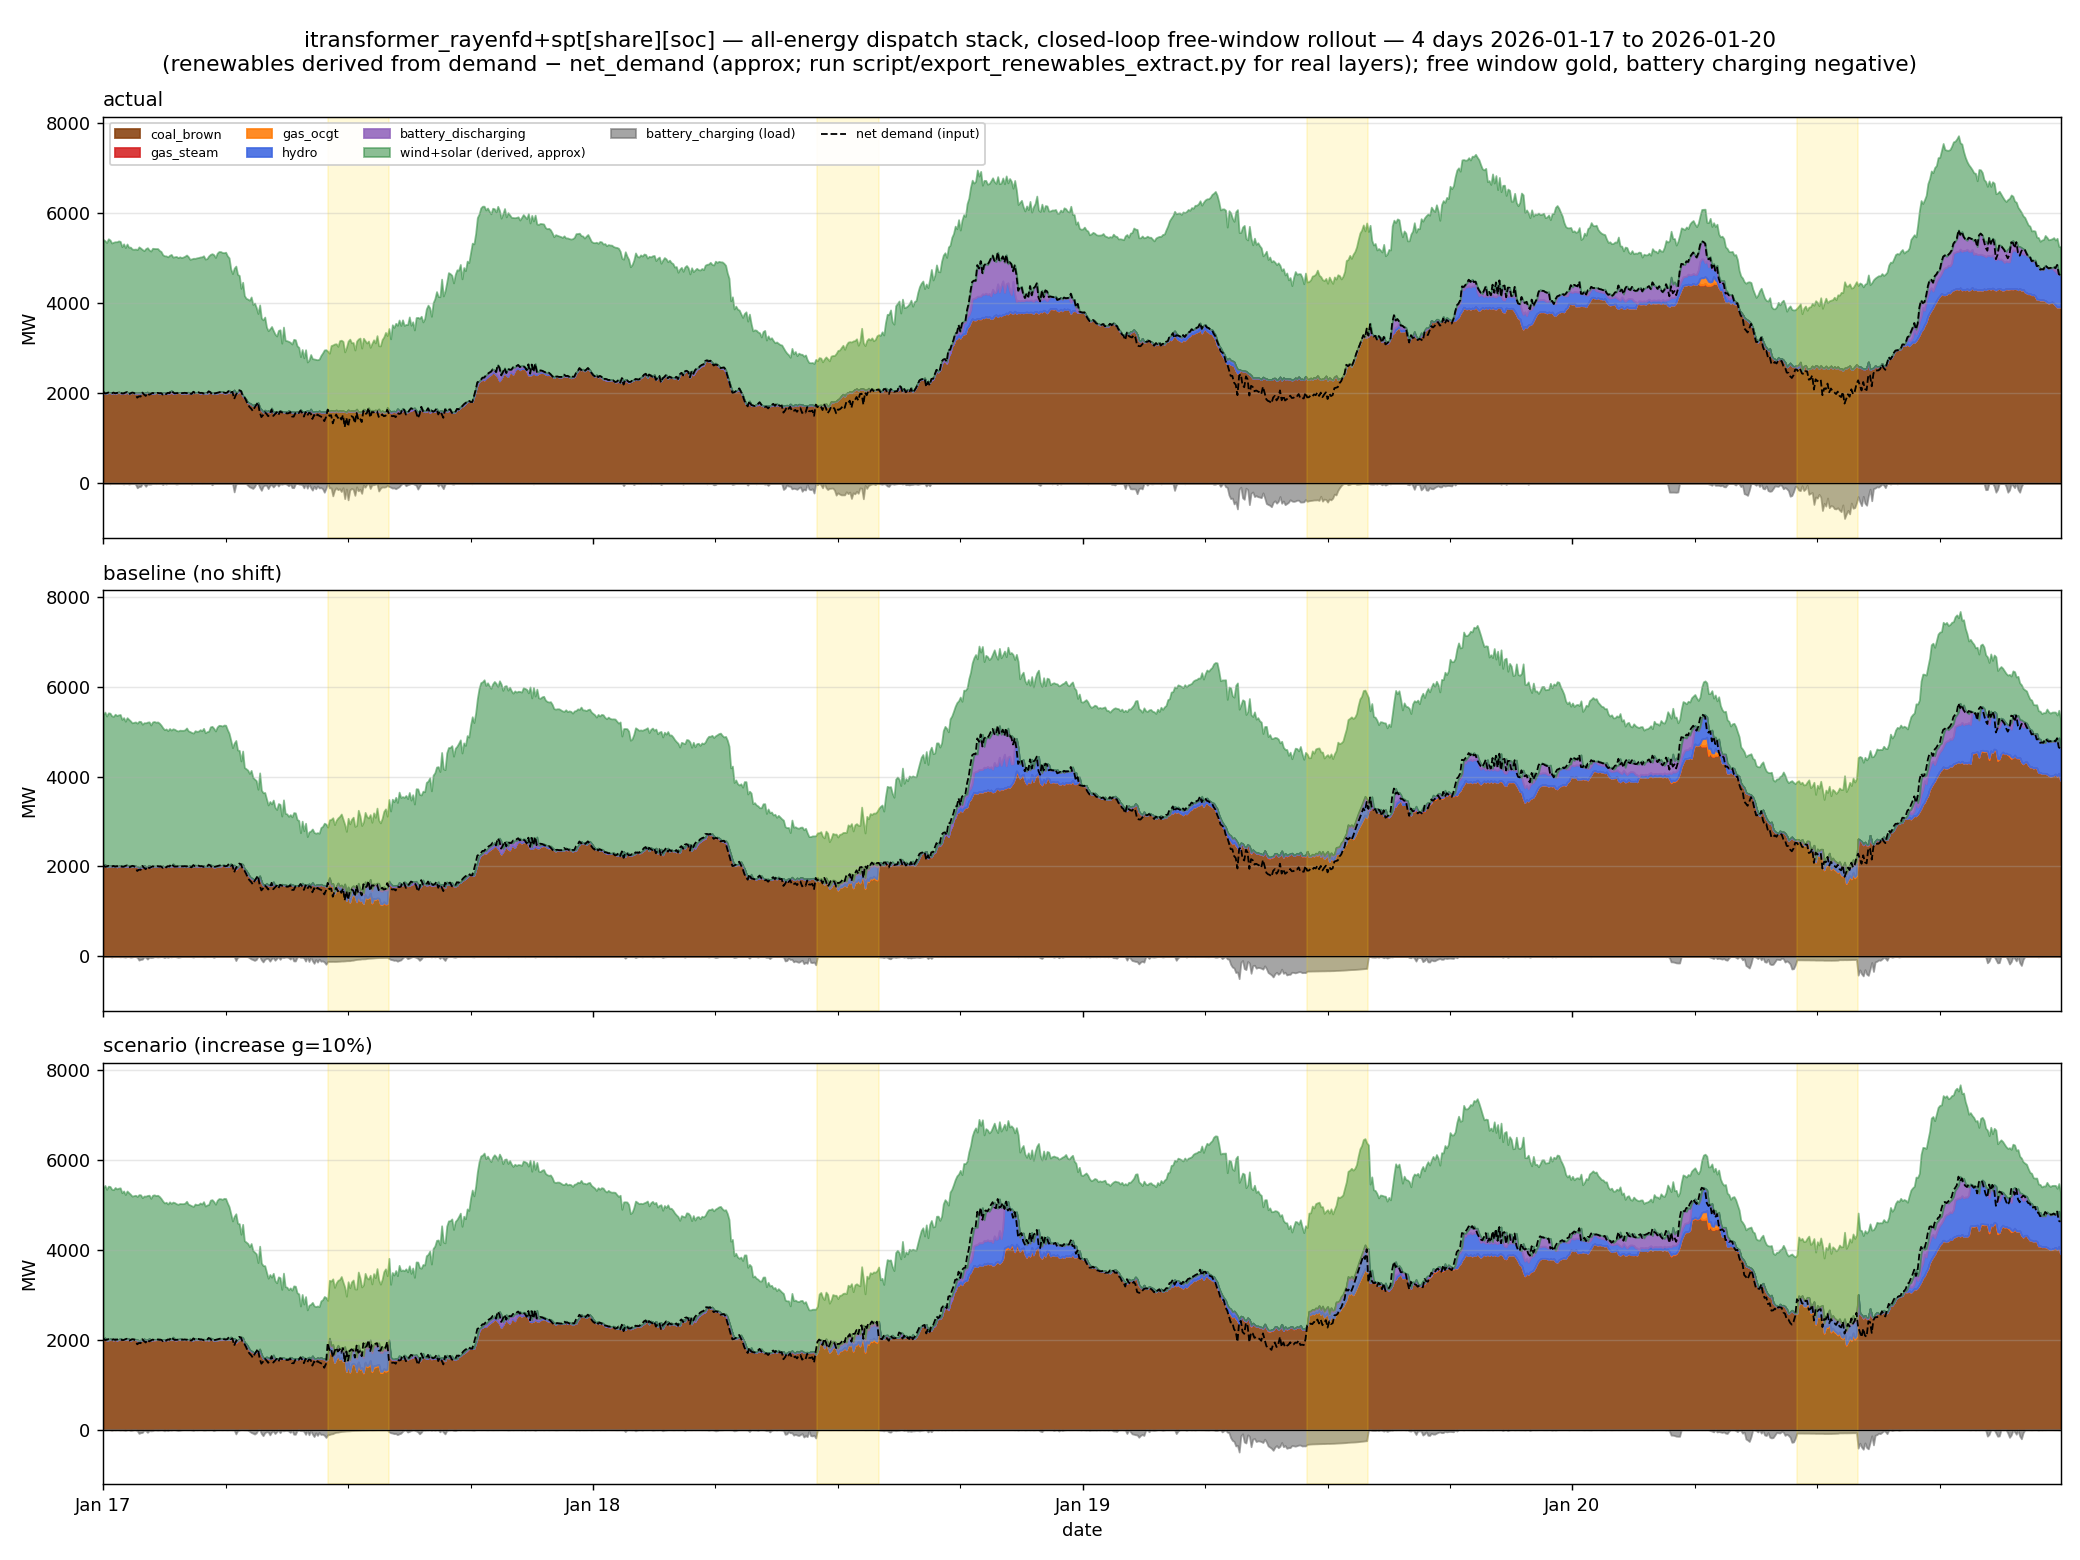

In [6]:
BEST_ALLOC, BEST_SHIELD = "share", "on"     # update after reading the verdict table
!python demand_simulation/study_stack_4day.py --model itransformer_rayenfd \
    --scenario increase --g 10 --fd-alloc $BEST_ALLOC --soc-shield $BEST_SHIELD
import glob, os
from IPython.display import Image, display
figs = sorted(glob.glob("demand_simulation/sweep_eqnd/study/figure/stacked_4day_*.png"),
              key=os.path.getmtime)
display(Image(figs[-1]))


## 6 · What to conclude / next

- Fix 1 shifts the response from batteries to coal/hydro (watch `batt_dis resp %`
  fall and `coal resp %` rise); fix 2 makes the battery budget a hard guarantee —
  `soc worst day %` can no longer cross 100.
- The head-level fixes are inference-time: the ultimate version bakes the
  allocation weights into the **retrain** (`ml/train_hist.py --arch
  itransformer_rayenfd`, study notebook step 3) so the backbone learns around them.
- Battery accuracy itself (WAPE ~0.25 floor) needs the battery-as-optimizer head —
  `constraints/lit_review.md` theme 6.
